# Cross-Market Revenue Forecasting and Customer Segmentation

This portfolio case study demonstrates an end-to-end workflow for customer-level revenue forecasting and behavioural segmentation across fictional regional codes.

- **Forecasting:** interpretable linear-regression baselines for each customer-region series.
- **Segmentation:** K-means clustering using revenue growth, purchase frequency, and average spend.
- **Validation:** rolling-origin forecast evaluation and an explicit audit of a one-year dataset-label offset.

> **Data note:** All records are deterministic synthetic data created for this public portfolio. They do not represent real customers, markets, or company performance.


## 1. Assumptions and scope

- Each forecasting row represents annual revenue for one fictional customer and regional code.
- The final historical year is treated as complete; the sharp decline is intentionally retained as a stress test.
- The one-year forecast covers 2026; the three-year forecast covers 2026–2028.
- The forecasting and segmentation files are analysed independently until their year labels are audited.
- The segmentation dataset contains one fictional geography.
- Negative revenue predictions are clipped to zero because negative customer revenue is not meaningful for this case.


In [1]:
# Libraries and project paths
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

FORECAST_FILE = PROJECT_ROOT / 'data' / 'forecasting.csv'
SEGMENT_FILE = PROJECT_ROOT / 'data' / 'segmentation.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Data folder: data/')
print('Output folder: outputs/')


Data folder: data/
Output folder: outputs/


## 2. Load and check the data

I first check row counts, columns, missing values, duplicate keys, year coverage, and the number of customers. These checks help confirm the data grain before modelling.

In [2]:
forecast = pd.read_csv(FORECAST_FILE)
segments = pd.read_csv(SEGMENT_FILE)

# Normalize column labels before validation.
forecast.columns = forecast.columns.str.strip()
segments.columns = segments.columns.str.strip()

print('Forecasting data shape:', forecast.shape)
print('Segmentation data shape:', segments.shape)
print('\nForecasting columns:', forecast.columns.tolist())
print('Segmentation columns:', segments.columns.tolist())
print('\nForecasting preview:')
print(forecast.head().to_string(index=False))

Forecasting data shape: (872, 4)
Segmentation data shape: (436, 6)

Forecasting columns: ['Customer ID', 'Region Code', 'Year', 'Revenue']
Segmentation columns: ['ID', 'Year', 'Geography', 'Revenue', 'Number of Purchases', 'Average Spend']

Forecasting preview:
 Customer ID Region Code  Year  Revenue
       10001      R-EAST  2018 7,423.56
       10001      R-EAST  2019 6,780.62
       10001      R-EAST  2020 7,466.51
       10001      R-EAST  2021 7,759.52
       10001      R-EAST  2022 8,265.92


In [3]:
print('Missing values in forecasting data:', forecast.isna().sum().sum())
print('Missing values in segmentation data:', segments.isna().sum().sum())

forecast_duplicates = forecast.duplicated(
    ['Customer ID', 'Region Code', 'Year']
).sum()
segment_duplicates = segments.duplicated(['ID', 'Year']).sum()

print('Forecast duplicate keys:', forecast_duplicates)
print('Segmentation duplicate keys:', segment_duplicates)
print('Forecast years:', sorted(forecast['Year'].unique()))
print('Segmentation years:', sorted(segments['Year'].unique()))
print('Forecast customers:', forecast['Customer ID'].nunique())
print('Segmentation customers:', segments['ID'].nunique())
print('Geographies:', segments['Geography'].unique())

assert forecast_duplicates == 0
assert segment_duplicates == 0
assert forecast['Revenue'].ge(0).all()
assert segments['Revenue'].ge(0).all()

Missing values in forecasting data: 0
Missing values in segmentation data: 0
Forecast duplicate keys: 0
Segmentation duplicate keys: 0
Forecast years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Segmentation years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Forecast customers: 109
Segmentation customers: 109
Geographies: ['Fictional Region']


### Check whether the two files use the same year labels

The files should not be joined automatically just because they contain the same customers and revenue field. I compare revenue in two ways:

1. customer and the same calendar year;
2. customer and segmentation year shifted forward by one.

This is a data-quality check, not part of the forecasting or clustering model.

In [4]:
# Same-year comparison for the years that exist in both files.
same_year_check = segments[['ID', 'Year', 'Revenue']].merge(
    forecast[['Customer ID', 'Year', 'Revenue']],
    left_on=['ID', 'Year'],
    right_on=['Customer ID', 'Year'],
    how='inner',
    suffixes=('_segmentation', '_forecasting')
)

same_year_match_rate = np.isclose(
    same_year_check['Revenue_segmentation'],
    same_year_check['Revenue_forecasting']
).mean()

# Shift the segmentation year by +1 and repeat the comparison.
shifted_year_source = segments[['ID', 'Year', 'Revenue']].copy()
shifted_year_source['Forecast Year'] = shifted_year_source['Year'] + 1

shifted_year_check = shifted_year_source.merge(
    forecast[['Customer ID', 'Year', 'Revenue']],
    left_on=['ID', 'Forecast Year'],
    right_on=['Customer ID', 'Year'],
    how='inner',
    suffixes=('_segmentation', '_forecasting')
)

shifted_year_match_rate = np.isclose(
    shifted_year_check['Revenue_segmentation'],
    shifted_year_check['Revenue_forecasting']
).mean()

print(f'Same-year revenue match: {same_year_match_rate:.1%}')
print(f'Revenue match after shifting segmentation year by +1: {shifted_year_match_rate:.1%}')
print('Rows compared after the shift:', len(shifted_year_check))

Same-year revenue match: 0.0%
Revenue match after shifting segmentation year by +1: 100.0%
Rows compared after the shift: 436


### Year-alignment finding

The same-year values do not match, while the revenue values match completely after shifting the segmentation year forward by one. This may mean that the files use different fiscal-year conventions, or it may be an off-by-one labelling issue.

I cannot decide which explanation is correct from the synthetic data. I therefore keep the exercises separate and would confirm the year definition with the data owner before combining the files.

      Total Revenue  Growth
Year                       
2018     953,108.32     NaN
2019   1,020,441.85    0.07
2020     997,255.97   -0.02
2021   1,104,869.50    0.11
2022   1,130,327.13    0.02
2023   1,133,462.27    0.00
2024   1,136,433.54    0.00
2025     678,798.89   -0.40


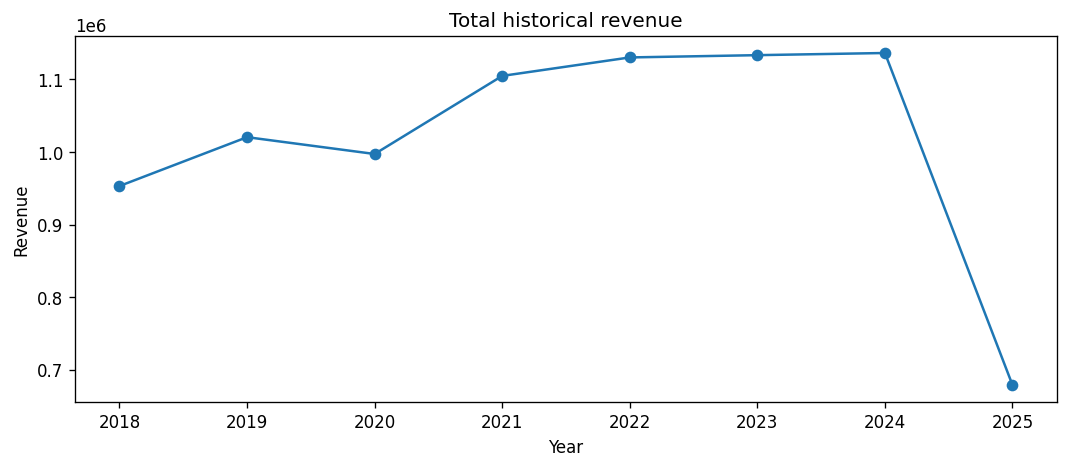

In [5]:
# Review total forecasting revenue over time.
annual_revenue = forecast.groupby('Year')['Revenue'].sum()
annual_growth = annual_revenue.pct_change()

print(pd.DataFrame({
    'Total Revenue': annual_revenue,
    'Growth': annual_growth
}).to_string())

annual_revenue.plot(marker='o', figsize=(9, 4), title='Total historical revenue')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### Data observation

Total revenue falls by approximately **40.3% in 2025**. The synthetic data deliberately includes this final-year shock to test whether the baseline remains reliable when the historical pattern changes.


## 3. Forecasting with linear regression

I chose linear regression because it is simple, interpretable, and suitable as a first trend model. For each customer-region pair, it learns a straight relationship between year and revenue:

`Revenue = intercept + slope × Year`

The slope represents the estimated yearly change in revenue. The main limitation is that a straight-line trend may not continue for three future years.

Linear regression rolling-validation results:
            Mean_Absolute_Error  WAPE  Bias
Target Year                                
2022                        809  7.8% -0.3%
2023                      1,000  9.6%  3.5%
2024                        795  7.6%  4.8%
2025                      4,762 76.5% 76.5%

Combined 2022–2025 WAPE: 19.7%


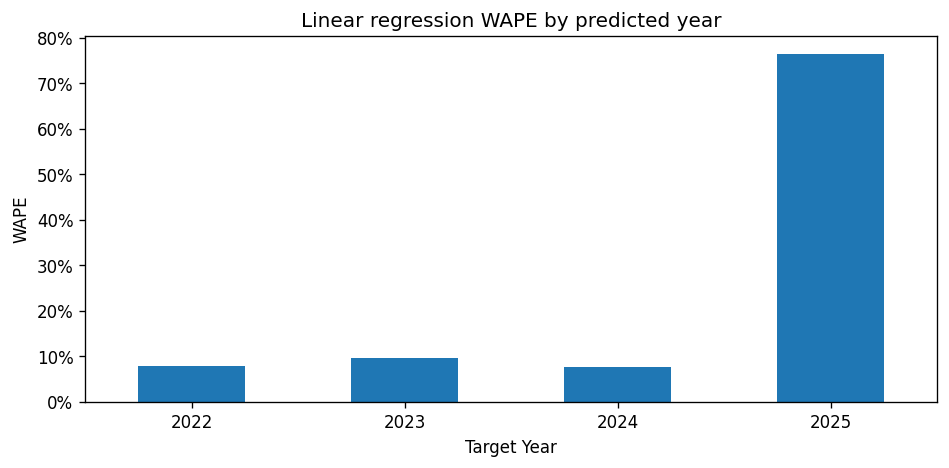

In [6]:
# Rolling validation of the chosen linear regression method.
validation_rows = []
validation_years = [2022, 2023, 2024, 2025]

for (customer_id, region_code), group in forecast.groupby(
    ['Customer ID', 'Region Code']
):
    group = group.sort_values('Year')

    for target_year in validation_years:
        train = group[group['Year'] < target_year]
        test = group[group['Year'] == target_year]

        model = LinearRegression()
        model.fit(train[['Year']], train['Revenue'])

        prediction = model.predict(test[['Year']])[0]
        prediction = max(0, prediction)
        actual = test['Revenue'].iloc[0]

        validation_rows.append({
            'Customer ID': customer_id,
            'Region Code': region_code,
            'Target Year': target_year,
            'Actual Revenue': actual,
            'Predicted Revenue': prediction,
            'Absolute Error': abs(actual - prediction),
            'Signed Error': prediction - actual
        })

validation_results = pd.DataFrame(validation_rows)

# Summarise performance across all customers for each predicted year.
validation_summary = validation_results.groupby('Target Year').agg(
    Actual_Revenue=('Actual Revenue', 'sum'),
    Absolute_Error=('Absolute Error', 'sum'),
    Mean_Absolute_Error=('Absolute Error', 'mean'),
    Signed_Error=('Signed Error', 'sum')
)

validation_summary['WAPE'] = (
    validation_summary['Absolute_Error']
    / validation_summary['Actual_Revenue'].abs()
)
validation_summary['Bias'] = (
    validation_summary['Signed_Error']
    / validation_summary['Actual_Revenue'].abs()
)

combined_wape = (
    validation_results['Absolute Error'].sum()
    / validation_results['Actual Revenue'].abs().sum()
)

print('Linear regression rolling-validation results:')
print(validation_summary[[
    'Mean_Absolute_Error', 'WAPE', 'Bias'
]].to_string(formatters={
    'Mean_Absolute_Error': '{:,.0f}'.format,
    'WAPE': '{:.1%}'.format,
    'Bias': '{:.1%}'.format
}))
print(f'\nCombined 2022–2025 WAPE: {combined_wape:.1%}')

validation_summary['WAPE'].plot(
    kind='bar', figsize=(8, 4), title='Linear regression WAPE by predicted year'
)
plt.ylabel('WAPE')
plt.gca().yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Validation conclusion

The model is reasonably accurate in the earlier rolling validation years, but fails to adapt to the final-year shock:

- 2022 WAPE: `7.8%`
- 2023 WAPE: `9.6%`
- 2024 WAPE: `7.6%`
- 2025 WAPE: `76.5%`
- Combined 2022–2025 WAPE: `19.7%`

This result is more informative than reporting one aggregate score alone. It shows that a stable historical relationship does not guarantee reliable forecasts after a structural change. Linear regression remains a useful interpretable baseline, but not a production-ready final model for this dataset.


In [7]:
# After validation, the chosen method has been fit again using all supplied years.

future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
forecast_rows = []

for (customer_id, region_code), group in forecast.groupby(
    ['Customer ID', 'Region Code']
):
    group = group.sort_values('Year')

    model = LinearRegression()
    model.fit(group[['Year']], group['Revenue'])

    predictions = model.predict(future_years)
    predictions = np.maximum(predictions, 0)

    for year, prediction in zip(future_years['Year'], predictions):
        forecast_rows.append({
            'Customer ID': customer_id,
            'Region Code': region_code,
            'Forecast Year': year,
            'Forecast Revenue': prediction,
            'Method': 'Linear Regression'
        })

forecast_3_years = pd.DataFrame(forecast_rows)
forecast_1_year = forecast_3_years[
    forecast_3_years['Forecast Year'] == 2026
].copy()

print('One-year forecast rows:', len(forecast_1_year))
print('Three-year forecast rows:', len(forecast_3_years))
print('\nOne-year forecast preview:')
print(forecast_1_year.head(10).to_string(index=False))

One-year forecast rows: 109
Three-year forecast rows: 327

One-year forecast preview:
 Customer ID Region Code  Forecast Year  Forecast Revenue            Method
       10001      R-EAST           2026          7,909.04 Linear Regression
       10002     R-SOUTH           2026         15,477.11 Linear Regression
       10003      R-WEST           2026          3,341.41 Linear Regression
       10004      R-EAST           2026          7,667.53 Linear Regression
       10005     R-NORTH           2026          7,967.27 Linear Regression
       10006      R-WEST           2026          6,807.34 Linear Regression
       10007      R-EAST           2026          4,249.03 Linear Regression
       10008      R-EAST           2026          5,838.67 Linear Regression
       10009     R-NORTH           2026          6,916.35 Linear Regression
       10010     R-SOUTH           2026          9,125.54 Linear Regression


Forecast totals:
Forecast Year
2026   970,794.45
2027   960,007.18
2028   949,219.90


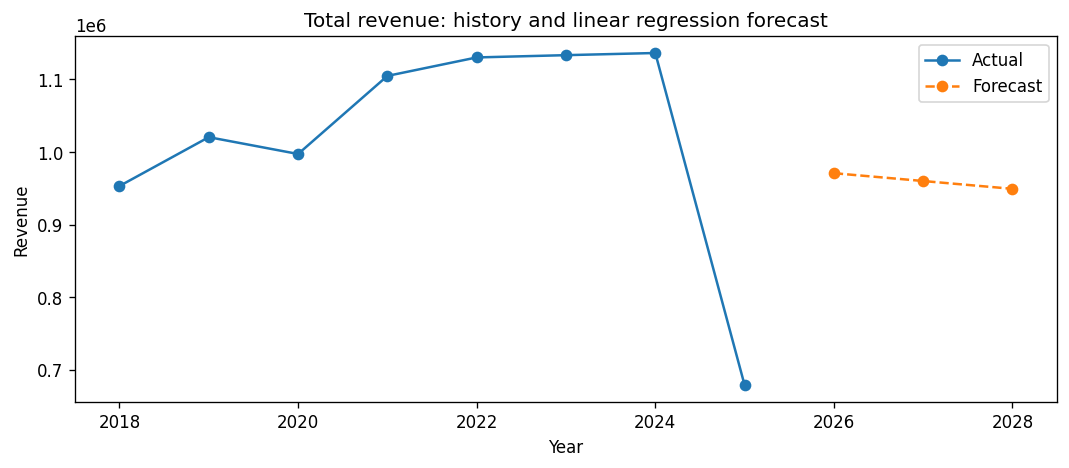

In [8]:
# Compare historical total revenue with the total forecast.
forecast_totals = forecast_3_years.groupby('Forecast Year')['Forecast Revenue'].sum()

plt.figure(figsize=(9, 4))
plt.plot(annual_revenue.index, annual_revenue.values, marker='o', label='Actual')
plt.plot(forecast_totals.index, forecast_totals.values,
         marker='o', linestyle='--', label='Forecast')
plt.title('Total revenue: history and linear regression forecast')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.show()

print('Forecast totals:')
print(forecast_totals.to_string())

## 4. Customer segmentation with K-means

I chose K-means because it is a common and understandable clustering method. I use the three behaviors specified in the task:

- year-over-year revenue growth;
- number of purchases;
- average spend.

I fit one model on pooled 2021–2023 observations so that the same cluster definitions are used in all three years.

I selected four clusters to keep enough behavioral differentiation while staying inside the working design. I am aware that three and four clusters could be compared with silhouette score. I did not add that comparison in this baseline because I wanted to focus on one clustering solution that I could profile and explain clearly.

In [9]:
# Calculate revenue growth separately for each customer.
segments = segments.sort_values(['ID', 'Year']).copy()
segments['Revenue Growth Rate'] = (
    segments.groupby('ID')['Revenue'].pct_change()
)

# Keep the three requested years after calculating growth.
segment_data = segments[
    segments['Year'].isin([2021, 2022, 2023])
].copy()

features = [
    'Revenue Growth Rate',
    'Number of Purchases',
    'Average Spend'
]

print(segment_data[features].describe().to_string())

       Revenue Growth Rate  Number of Purchases  Average Spend
count               327.00               327.00         327.00
mean                  0.01                34.59         408.29
std                   0.10                17.27         403.77
min                  -0.29                 9.00          65.62
25%                  -0.07                20.00         159.84
50%                   0.01                30.00         294.08
75%                   0.07                46.00         469.97
max                   0.33                68.00       3,730.07


In [10]:
# Scaling is needed because purchases, spend, and growth use different units.
# Without scaling, the feature with the largest numerical values could dominate
# the distance calculation used by K-means.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(segment_data[features])

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

segment_data['Cluster'] = kmeans.fit_predict(scaled_features)

cluster_profile = segment_data.groupby('Cluster').agg(
    Customer_Years=('ID', 'size'),
    Average_Growth=('Revenue Growth Rate', 'mean'),
    Average_Purchases=('Number of Purchases', 'mean'),
    Average_Spend=('Average Spend', 'mean'),
    Average_Revenue=('Revenue', 'mean')
)

print(cluster_profile.to_string())

         Customer_Years  Average_Growth  Average_Purchases  Average_Spend  Average_Revenue
Cluster                                                                                   
0                    24            0.05              16.75       1,491.63        24,056.52
1                   102            0.09              25.21         446.57        10,452.57
2                    86            0.02              59.12         163.03         9,597.57
3                   115           -0.09              28.29         331.65         8,098.37


### Preprocessing scope

For this version I use standard scaling only. K-means can also be affected by highly skewed values and outliers. With more time, I would first inspect the feature distributions.

I did not add those transformations automatically because they can change customer distances, cluster assignments, and therefore the segment definitions. I would want to confirm that any transformed solution was both statistically reasonable and easier to interpret for the business.

### Cluster interpretation

The fitted cluster profiles support four working labels:

- **Cluster 0 — High-value / high-spend:** the largest average revenue and basket size.
- **Cluster 1 — Growing mid-value:** the strongest average growth with moderate purchase frequency.
- **Cluster 2 — Frequent lower-basket:** the highest purchase frequency but a smaller average transaction.
- **Cluster 3 — Declining lower-value:** negative average growth and the lowest average revenue.

These labels summarize this synthetic dataset; they are not permanent business definitions. Any production segmentation would need stakeholder review and stability testing.


Customers in each segment by year:
Segment  Declining lower-value  Frequent lower-basket  Growing mid-value  High-value / high-spend
Year                                                                                             
2021                        36                     27                 41                        5
2022                        39                     28                 32                       10
2023                        40                     31                 29                        9


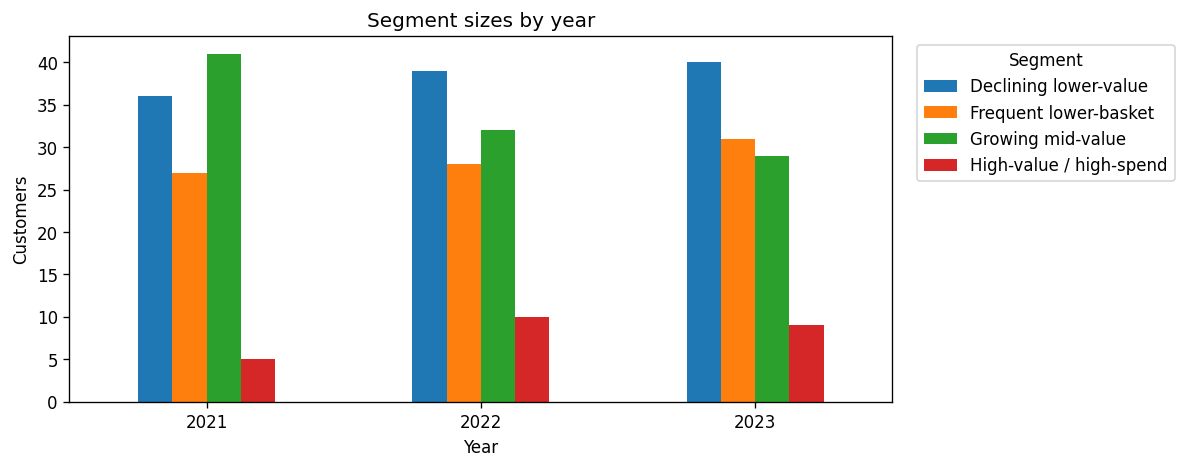

In [11]:
# The fixed random state makes these cluster numbers reproducible.
cluster_names = {
    0: 'High-value / high-spend',
    1: 'Growing mid-value',
    2: 'Frequent lower-basket',
    3: 'Declining lower-value'
}

segment_data['Segment'] = segment_data['Cluster'].map(cluster_names)

segment_sizes = pd.crosstab(segment_data['Year'], segment_data['Segment'])
print('Customers in each segment by year:')
print(segment_sizes.to_string())

segment_sizes.plot(kind='bar', figsize=(10, 4))
plt.title('Segment sizes by year')
plt.xlabel('Year')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Customer movement between segments

I reshape the results so each customer has one segment column for 2021, 2022, and 2023. Cross-tabulations then show how many customers moved from each starting segment to each following-year segment.

Movement from 2021 to 2022:
2022                     Declining lower-value  Frequent lower-basket  Growing mid-value  High-value / high-spend
2021                                                                                                             
Declining lower-value                       17                      2                 15                        2
Frequent lower-basket                        2                     25                  0                        0
Growing mid-value                           20                      1                 16                        4
High-value / high-spend                      0                      0                  1                        4

Movement from 2022 to 2023:
2023                     Declining lower-value  Frequent lower-basket  Growing mid-value  High-value / high-spend
2022                                                                                                             
Declining lower-value          

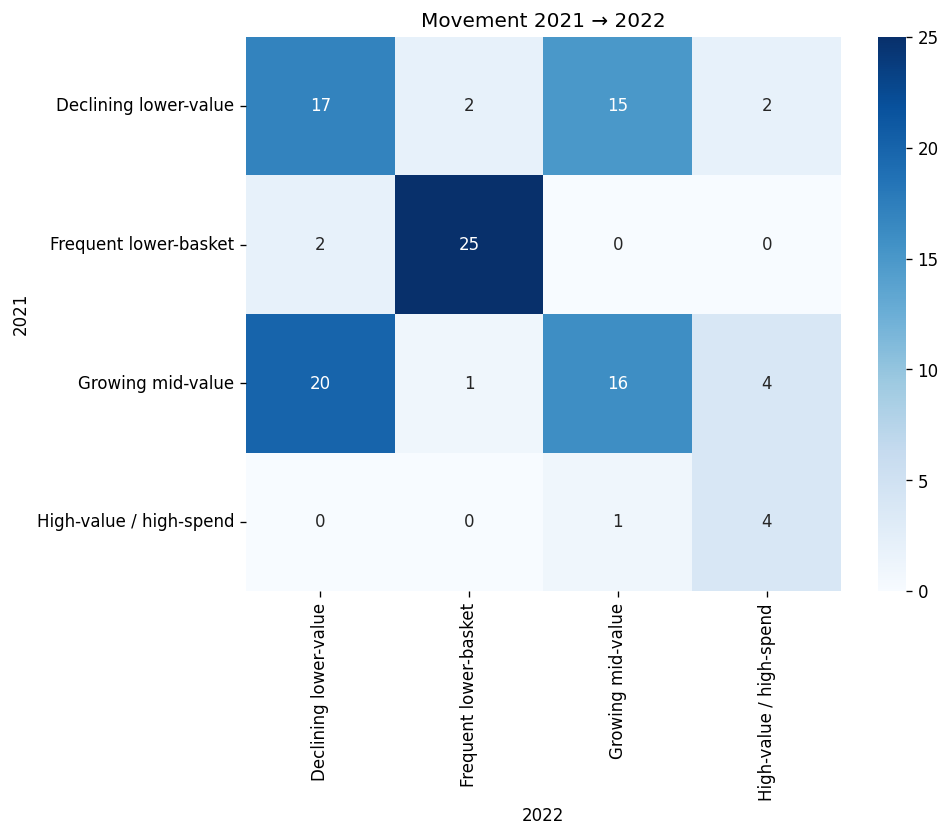

In [12]:
customer_movement = segment_data.pivot(
    index='ID',
    columns='Year',
    values='Segment'
)

movement_2021_2022 = pd.crosstab(
    customer_movement[2021],
    customer_movement[2022]
)

movement_2022_2023 = pd.crosstab(
    customer_movement[2022],
    customer_movement[2023]
)

print('Movement from 2021 to 2022:')
print(movement_2021_2022.to_string())
print('\nMovement from 2022 to 2023:')
print(movement_2022_2023.to_string())
print('\nMovement 2021 → 2022 heatmap')

plt.figure(figsize=(8,6))
sns.heatmap(movement_2021_2022, annot=True, fmt='d', cmap='Blues')
plt.title('Movement 2021 → 2022')
plt.show()


## 6. Conclusions and limitations

### Forecasting

- Linear regression provides a transparent downward-trend baseline for 2026–2028.
- Rolling validation shows whether the method remains reliable as the forecast origin moves forward.
- The deliberately sharp final-year shock exposes an important limitation: a simple trend model reacts poorly to structural change.

### Segmentation

- K-means creates four behavioural groups using growth, purchases, and average spend.
- Segment labels are working business descriptions, not permanent customer identities.
- K-means is sensitive to skew, outliers, scaling, and the selected number of clusters; production use would require stability checks.

### Cross-market scope

The segmentation data contains only one fictional geography, so the results are not presented as globally transferable segments. A multi-market extension would require local validation of feature definitions, value distributions, and segment profiles.

### Practical next steps

Before operational use, I would compare this baseline with a naïve forecast, investigate the final-year decline, assess forecast intervals, and test whether the customer segments remain stable across time and markets.


In [13]:
# Export the main results.
forecast_1_year.to_csv(OUTPUT_DIR / 'simple_forecast_1_year.csv', index=False)
forecast_3_years.to_csv(OUTPUT_DIR / 'simple_forecast_3_years.csv', index=False)
validation_summary.reset_index().to_csv(
    OUTPUT_DIR / 'simple_linear_regression_validation.csv', index=False
)

segment_output = segment_data[[
    'ID', 'Year', 'Revenue', 'Revenue Growth Rate',
    'Number of Purchases', 'Average Spend', 'Cluster', 'Segment'
]].sort_values(['ID', 'Year'])

segment_output.to_csv(
    OUTPUT_DIR / 'simple_customer_segments_2021_2023.csv',
    index=False
)
movement_2021_2022.to_csv(OUTPUT_DIR / 'simple_movement_2021_2022.csv')
movement_2022_2023.to_csv(OUTPUT_DIR / 'simple_movement_2022_2023.csv')

# Basic checks before finishing.
series_count = forecast[['Customer ID', 'Region Code']].drop_duplicates().shape[0]
assert len(forecast_1_year) == series_count
assert len(forecast_3_years) == series_count * 3
assert len(segment_output) == segments['ID'].nunique() * 3
assert segment_output['Segment'].notna().all()
assert forecast_3_years['Forecast Revenue'].ge(0).all()
assert len(validation_results) == series_count * len(validation_years)
assert shifted_year_match_rate == 1.0

print('All result files saved successfully.')

All result files saved successfully.
